In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("Social_Network_Ads.csv")
df=df.iloc[:,2:]
df.sample(5)

,Age,EstimatedSalary,Purchased
354,36,99000,1
309,38,50000,0
111,37,71000,0
146,27,96000,1
106,26,35000,0


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.3,random_state=0)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((280, 2), (120, 2), (280,), (120,))

# StandardScaler

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)


,copy,True
,with_mean,True
,with_std,True


In [8]:
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [9]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [10]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [11]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [12]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


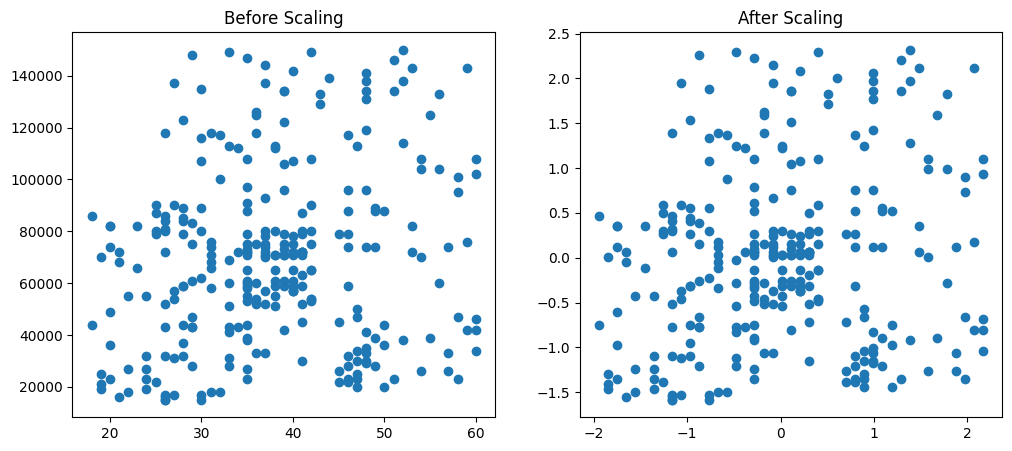

In [13]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
ax1.scatter(X_train["Age"],X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"])
ax2.set_title("After Scaling")
plt.show()

<Axes: title={'center': 'After stander scaling'}, xlabel='Age', ylabel='Density'>

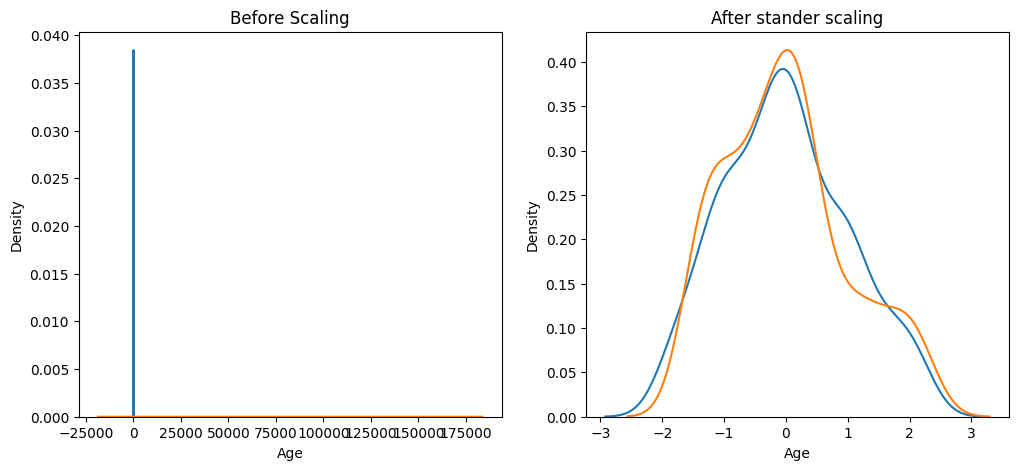

In [14]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
# Before scalling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
# After scalling
ax2.set_title("After stander scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

<Axes: title={'center': 'Age After stander scaling'}, xlabel='Age', ylabel='Density'>

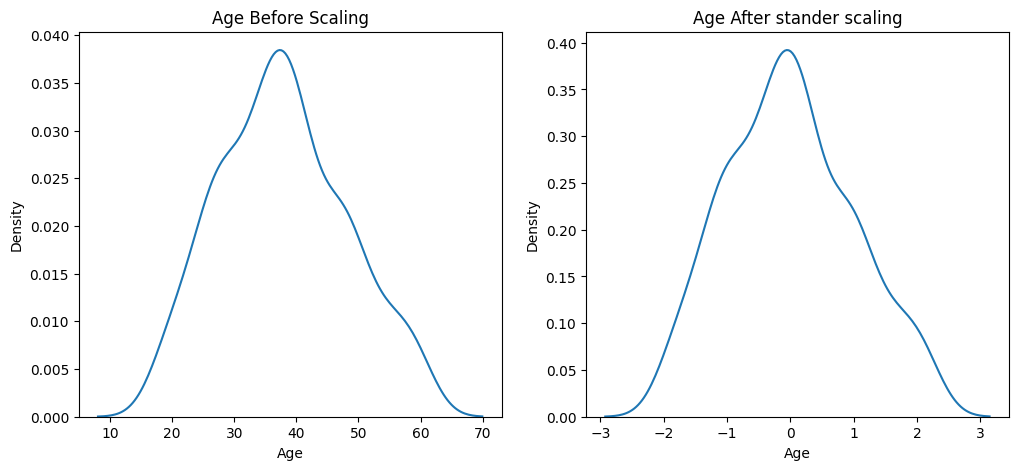

In [15]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
# Before scalling
ax1.set_title("Age Before Scaling")
sns.kdeplot(X_train["Age"],ax=ax1)
# sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
# After scalling
ax2.set_title("Age After stander scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
# sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

<Axes: title={'center': 'Salary After stander scaling'}, xlabel='EstimatedSalary', ylabel='Density'>

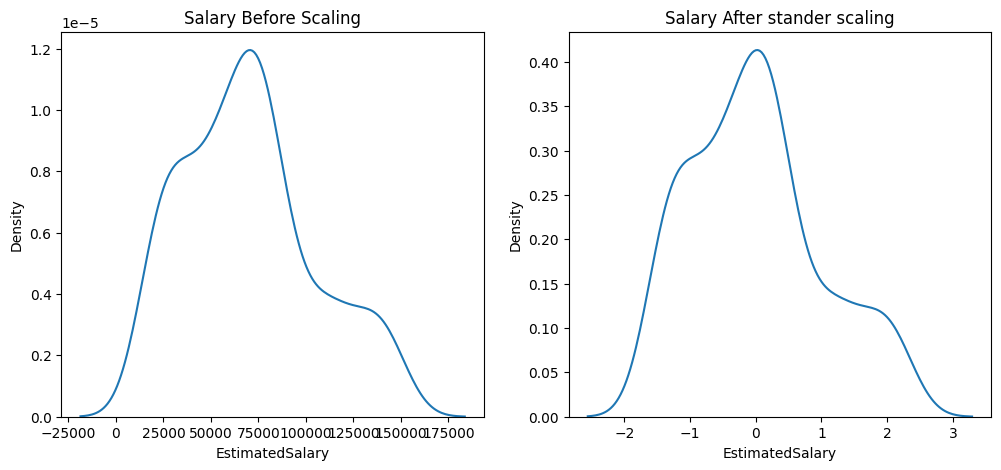

In [16]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
# Before scalling
ax1.set_title("Salary Before Scaling")
# sns.kdeplot(X_train["Age"],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
# After scalling
ax2.set_title("Salary After stander scaling")
# sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

# Why Scaling is importent

In [18]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [19]:
lr.fit(X_train,Y_train)
lr_scaled.fit(X_train_scaled,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
Y_pred=lr.predict(X_test)
Y_pred_scaled=lr_scaled.predict(X_test_scaled)


In [25]:
from sklearn.metrics import accuracy_score

In [26]:
print("Accuracy before scaling:",accuracy_score(Y_test,Y_pred))
print("Accuracy after scaling:",accuracy_score(Y_test,Y_pred_scaled))

Accuracy before scaling: 0.875
Accuracy after scaling: 0.8666666666666667


In [27]:
from sklearn.tree import DecisionTreeClassifier


In [28]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

In [29]:
dt.fit(X_train,Y_train)
dt_scaled.fit(X_train_scaled,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
Y_pred=dt.predict(X_test)
Y_pred_scaled=dt_scaled.predict(X_test_scaled)

In [31]:
print("Accuracy before scaling:",accuracy_score(Y_test,Y_pred))
print("Accuracy after scaling:",accuracy_score(Y_test,Y_pred_scaled))

Accuracy before scaling: 0.875
Accuracy after scaling: 0.875


In [32]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [34]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


# Effect of outlier

In [35]:
df = pd.concat([df, pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})], ignore_index=True)

In [36]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


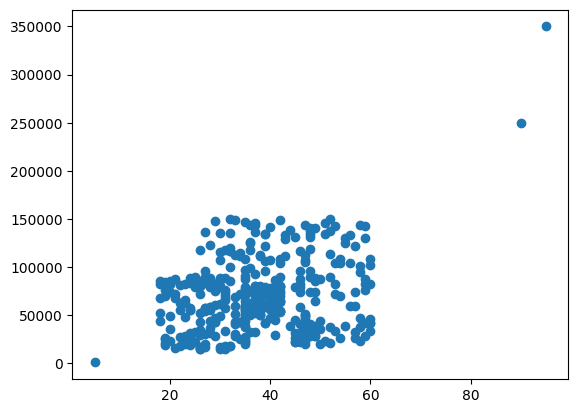

In [37]:
plt.scatter(df['Age'],df['EstimatedSalary'])

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [39]:
X_train,X_test,Y_train,Y_test=train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.3,random_state=0)

In [40]:
scaler=StandardScaler()

In [41]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [42]:
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [43]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

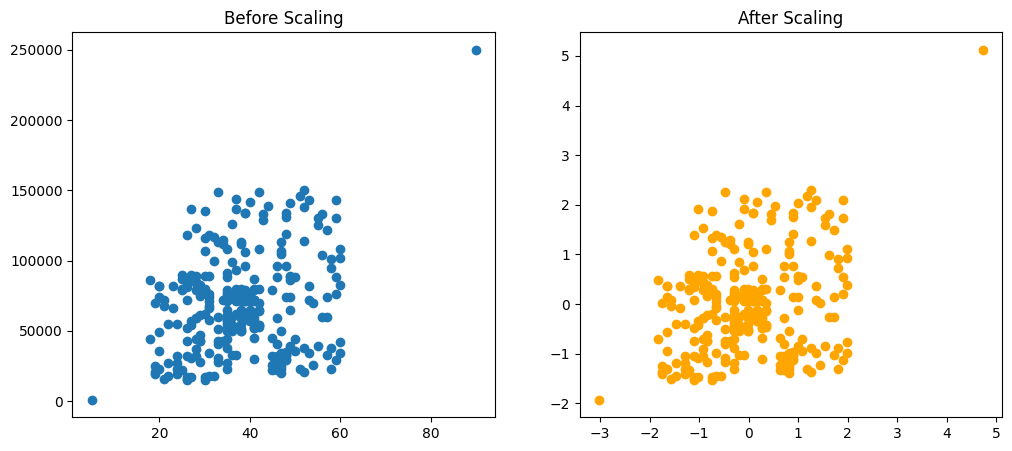

In [45]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
ax1.scatter(X_train["Age"],X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color='orange')
ax2.set_title("After Scaling")
plt.show()